In [21]:
import tensorflow as tf

In [22]:
tf.__version__

'2.20.0'

In [23]:
# handwritten digit => 28 * 28

mnist = tf.keras.datasets.mnist



In [24]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [25]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

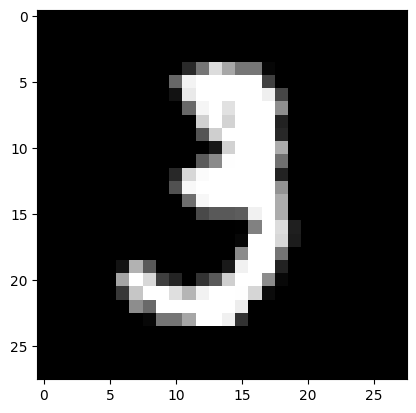

In [26]:
# visualize

import matplotlib.pyplot as plt
plt.imshow(x_train[10], cmap='gray')
plt.show()

In [27]:
print(y_train[10])

3


In [28]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

In [29]:
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

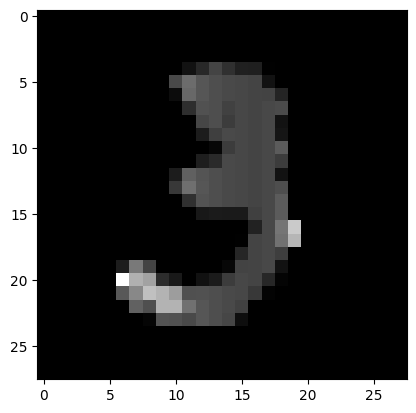

In [30]:
# visualize

import matplotlib.pyplot as plt
plt.imshow(x_train[10], cmap='gray')
plt.show()

In [31]:
# let we build a model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten()) # 28 * 28 image => 784 neurons  => 1D => 1 * 784

In [32]:
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu)) # for hidden i have 128 node => Relu activation func
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax)) # for output i have 10 node => Softmax activation func

In [33]:
# optimize / train
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [34]:
model.fit(x_train, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9220 - loss: 0.2656
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9664 - loss: 0.1079
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9782 - loss: 0.0713


In [35]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(val_loss, val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9734 - loss: 0.0880
0.08800356835126877 0.9733999967575073


In [36]:
prediction = model.predict(x_test)
print(prediction)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1.4256393e-07 1.9417755e-08 2.5501007e-05 ... 9.9996191e-01
  3.3520742e-08 2.5741534e-07]
 [4.2515683e-08 1.6362272e-04 9.9983001e-01 ... 9.2322388e-08
  1.3512231e-07 7.1199624e-10]
 [1.9190188e-07 9.9874598e-01 1.5007413e-04 ... 7.4240391e-04
  1.2723626e-04 6.5835115e-06]
 ...
 [1.2829589e-09 4.1652573e-08 5.6563954e-09 ... 2.4502206e-05
  1.4121078e-06 8.7895896e-06]
 [1.7575603e-06 6.1940773e-07 4.7228770e-07 ... 9.8883756e-06
  4.5755841e-03 4.1825894e-09]
 [1.1318260e-07 1.5926083e-10 2.2726645e-07 ... 1.3022784e-10
  3.9993406e-08 3.6420120e-11]]


In [37]:
import numpy as np
np.argmax(prediction[10])

np.int64(0)

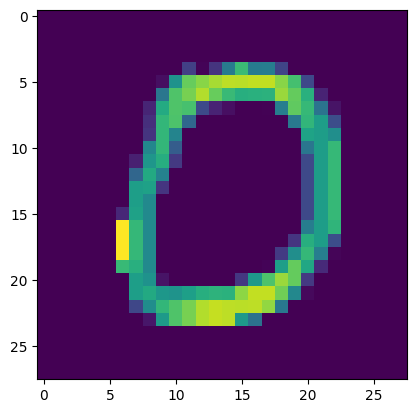

In [38]:
plt.imshow(x_test[10])
plt.show()

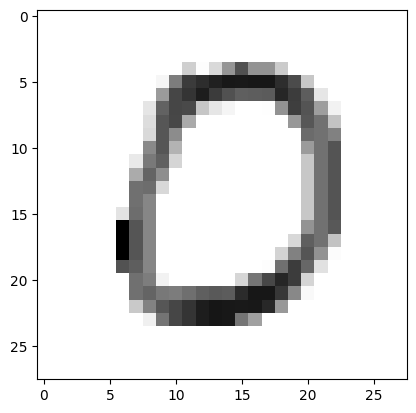

In [39]:
plt.imshow(x_test[10], cmap = plt.cm.binary)
plt.show()

In [41]:
np.argmax(prediction[7])

np.int64(9)

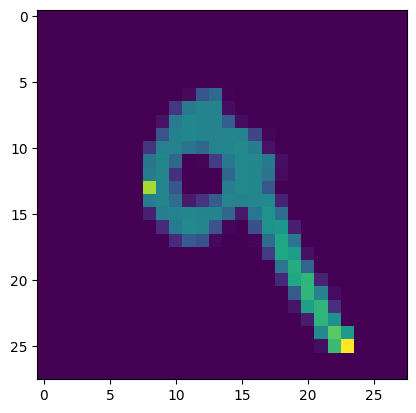

In [42]:
plt.imshow(x_test[7])
plt.show()